In [262]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt



In [263]:
df = pd.read_csv('london_weather.csv')

In [264]:
df.isnull().sum() 

date                   0
cloud_cover           19
sunshine               0
global_radiation      19
max_temp               6
mean_temp             36
min_temp               2
precipitation          6
pressure               4
snow_depth          1441
dtype: int64

In [265]:
df.shape

(15341, 10)

In [266]:
df

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
0,19790101,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0
1,19790102,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0
2,19790103,5.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0
3,19790104,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0
4,19790105,6.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0
...,...,...,...,...,...,...,...,...,...,...
15336,20201227,1.0,0.9,32.0,7.5,7.5,7.6,2.0,98000.0,NaN
15337,20201228,7.0,3.7,38.0,3.6,1.1,-1.3,0.2,97370.0,NaN
15338,20201229,7.0,0.0,21.0,4.1,2.6,1.1,0.0,98830.0,NaN
15339,20201230,6.0,0.4,22.0,5.6,2.7,-0.1,0.0,100200.0,NaN


In [267]:
# calculating the missing cloumns average temperatures
na = df[df['snow_depth'].isnull()]
not_na = df[df['snow_depth'].notna()]

print(" average mean temperature where the snow depth data was missing: ", na['mean_temp'].mean())
print("average max temperature where the snow depth data was missing: ", na['max_temp'].mean())
print("average min temperature where the snow depth data was missing: ", na['min_temp'].mean())
print(" average mean temperature where the snow depth data was not missing: ", not_na['mean_temp'].mean())
print("average max temperature where the snow depth data was not missing: ", not_na['max_temp'].mean())
print("average min temperature where the snow depth data was not missing: ", not_na['min_temp'].mean())

 average mean temperature where the snow depth data was missing:  15.264044943820224
average max temperature where the snow depth data was missing:  19.60020905923345
average min temperature where the snow depth data was missing:  10.941348158443363
 average mean temperature where the snow depth data was not missing:  11.086859736330235
average max temperature where the snow depth data was not missing:  14.954
average min temperature where the snow depth data was not missing:  7.209798561151079


In [268]:
df = df.drop(columns=['date'])

df = df.dropna(subset=['precipitation'])
df = df.fillna(df.mean())



In [269]:
X = df.drop(columns=['precipitation'])
y = df['precipitation']

In [270]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [271]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [289]:
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
r2

0.15988861289240464

In [290]:
model.intercept_


np.float64(109.90595134229659)

In [291]:
model.coef_ 

array([ 0.13163373, -0.13647477, -0.00096425, -0.06475824,  0.26142406,
       -0.16639552, -0.00107325, -0.00950408])

In [292]:
# using transformation
Min = X_train.min()
Max = X_train.max()

X_train_s = (X_train - Min) / (Max - Min)
X_test_s = (X_test - Min) / (Max - Min)

model_s = LinearRegression()
model_s.fit(X_train_s, y_train)

y_pred_s = model_s.predict(X_test_s)
r2_s = r2_score(y_test, y_pred_s)

print(f"R2 score after Min max transformation: {r2_s}")

R2 score after Min max transformation: 0.1598886128924042


In [293]:
# second attempt
# second attempt: standardization (z-score)
Mean = X_train.mean()
Std = X_train.std()

X_train_z = (X_train - Mean) / Std
X_test_z = (X_test - Mean) / Std

model_z = LinearRegression()
model_z.fit(X_train_z, y_train)

y_pred_z = model_z.predict(X_test_z)
r2_z = r2_score(y_test, y_pred_z)

print(f"R2 score after Standardization: {r2_z}")

R2 score after Standardization: 0.1598886128924042


In [294]:
X_train.skew()

cloud_cover         -0.690674
sunshine             0.685844
global_radiation     0.650528
max_temp             0.122395
mean_temp           -0.015281
min_temp            -0.171492
pressure            -0.429017
snow_depth          24.072137
dtype: float64

In [295]:
np.log10(101325)

np.float64(5.005716612413731)

In [296]:
max_a = X_train.abs().max()

d = np.ceil(np.log10(max_a))

X_train_d = X_train /(10 ** d)

X_test_d = (X_test / (10 ** d))

model_d = LinearRegression()

model_d.fit(X_train_d, y_train)

y_pred_d = model_d.predict(X_test_d)

r2_d = r2_score(y_test, y_pred_d)

print(f"R2 score after Decimal Scaling: {r2_d}")

R2 score after Decimal Scaling: 0.1598886128924042


In [297]:
# Feature selection
train = X_train_z.copy()
train['precipitation'] = y_train.values
cor = train.corr(method = "pearson")
print(cor)

                  cloud_cover  sunshine  global_radiation  max_temp  \
cloud_cover          1.000000 -0.735378         -0.483367 -0.210819   
sunshine            -0.735378  1.000000          0.850651  0.473137   
global_radiation    -0.483367  0.850651          1.000000  0.689287   
max_temp            -0.210819  0.473137          0.689287  1.000000   
mean_temp           -0.108864  0.398950          0.634756  0.911667   
min_temp             0.050988  0.222229          0.478761  0.811387   
pressure            -0.239329  0.220929          0.144387  0.093661   
snow_depth           0.001338 -0.034477         -0.058957 -0.123310   
precipitation        0.232812 -0.233732         -0.164560 -0.069672   

                  mean_temp  min_temp  pressure  snow_depth  precipitation  
cloud_cover       -0.108864  0.050988 -0.239329    0.001338       0.232812  
sunshine           0.398950  0.222229  0.220929   -0.034477      -0.233732  
global_radiation   0.634756  0.478761  0.144387   -0.05895

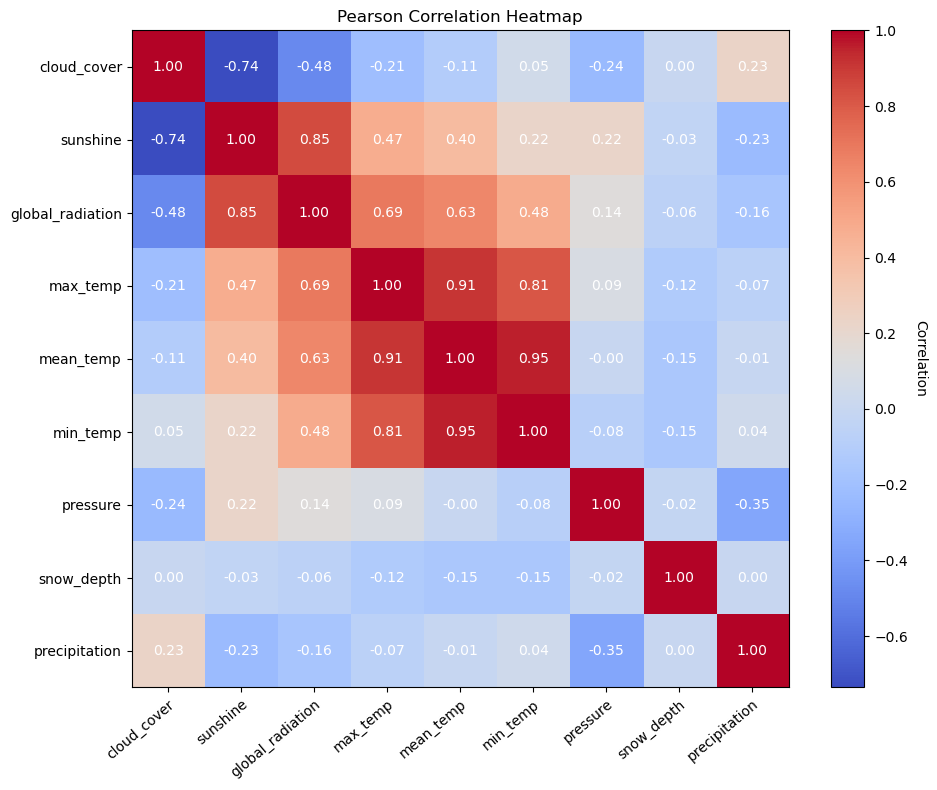

In [298]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(cor.values, cmap='coolwarm')

ax.set_xticks(np.arange(len(cor.columns)), labels=cor.columns)
ax.set_yticks(np.arange(len(cor.columns)), labels=cor.columns)

plt.setp(ax.get_xticklabels(), rotation=40, ha='right', rotation_mode='anchor')

for i in range(len(cor.columns)):
    for j in range(len(cor.columns)):
        ax.text(j, i, f'{cor.iloc[i, j]:.2f}', ha='center', va='center', color='w')

cbar = ax.figure.colorbar(ax.images[0], ax=ax)
cbar.ax.set_ylabel("Correlation", rotation=-90, va="bottom")

plt.title('Pearson Correlation Heatmap')
plt.tight_layout()
plt.show()

In [299]:
dropped = X_train_z.drop(columns=['min_temp', 'max_temp', 'sunshine'])
X_test_d = X_test_z.drop(columns=['min_temp', 'max_temp', 'sunshine'])
model_f = LinearRegression()
model_f.fit(dropped, y_train)
y_pred_f = model_f.predict(X_test_d)
r2_f = r2_score(y_test, y_pred_f)
print(f"R2 after Feature Selection Attempt 1: {r2_f}")


R2 after Feature Selection Attempt 1: 0.15759492732677283


In [300]:
#second attempt
dropped2 = X_train_z.drop(columns=['min_temp', 'max_temp'])
X_test_d2 = X_test_z.drop(columns=['min_temp', 'max_temp'])
model_f2 = LinearRegression()
model_f2.fit(dropped2, y_train)
y_pred_f2 = model_f2.predict(X_test_d2)
r2_f2 = r2_score(y_test, y_pred_f2)
print(f"R2 after Feature Selection Attempt 2: {r2_f2}")

R2 after Feature Selection Attempt 2: 0.1567163846425731


In [301]:
dropped3 = X_train_z.drop(columns=['snow_depth'])
X_test_d3 = X_test_z.drop(columns=['snow_depth' ])
model_f3 = LinearRegression()
model_f3.fit(dropped3, y_train)
y_pred_f3 = model_f3.predict(X_test_d3)
r2_f3 = r2_score(y_test, y_pred_f3)
print(f"R2 after Feature Selection Attempt 3: {r2_f3}")

R2 after Feature Selection Attempt 3: 0.1598502106330748


In [302]:
# OOutlier Detection Attempt 1 - T=3.5, m=1
z_scores = (X_train_z - X_train_z.mean()) / X_train_z.std()
outlier = (z_scores.abs() > 3.5).sum(axis=1) >= 1
X_train_o1 = X_train_z[~outlier]
y_train_o1 = y_train[~outlier]

model_o1 = LinearRegression()
model_o1.fit(X_train_o1, y_train_o1)
r2_o1 = r2_score(y_test, model_o1.predict(X_test_z))
print(f"R2 after Outlier Detection Attempt 1: {r2_o1}")
print(f"Rows removed: {outlier.sum()}")

R2 after Outlier Detection Attempt 1: 0.15899637218101847
Rows removed: 89


In [303]:
# Outlier Detection Attempt 2 , T=3.5, m=2
z_scores2 = (X_train_z - X_train_z.mean()) / X_train_z.std()
outlier2 = (z_scores2.abs() > 3.5).sum(axis=1) >= 2
X_train_o2 = X_train_z[~outlier2]
y_train_o2 = y_train[~outlier2]

model_o2 = LinearRegression()
model_o2.fit(X_train_o2, y_train_o2)
r2_o2 = r2_score(y_test, model_o2.predict(X_test_z))
print(f"R2 after Outlier Detection Attempt 2: {r2_o2}")
print(f"Rows removed: {outlier2.sum()}")

R2 after Outlier Detection Attempt 2: 0.16011823181063012
Rows removed: 1


In [304]:
# Outlier Detetion Attempt 3 - T=3, m=3
z_scores3 = (X_train_o2 - X_train_o2.mean()) / X_train_o2.std()
outlier3 = (z_scores3.abs() > 3).sum(axis=1) >= 3
X_train_o3 = X_train_o2[~outlier3]
y_train_o3 = y_train_o2[~outlier3]

model_o3 = LinearRegression()
model_o3.fit(X_train_o3, y_train_o3)
r2_o3 = r2_score(y_test, model_o3.predict(X_test_z))
print(f"R2 after Outlier Detection Attempt 3: {r2_o3}")
print(f"Rows removed: {outlier3.sum()}")

R2 after Outlier Detection Attempt 3: 0.16011823181063012
Rows removed: 0


In [306]:

# FINAL R2 SCORE

print(f"FINAL R2: {r2_o2}")
print("Achieved using: Outlier Detection Attempt 2 (T=3.5, m=2)")
print("Pipeline: Baseline -> Standardization -> Outlier Detection (T=3.5, m=2)"

FINAL R2: 0.16011823181063012
Achieved using: Outlier Detection Attempt 2 (T=3.5, m=2)
Pipeline: Baseline -> Standardization -> Outlier Detection (T=3.5, m=2)


Stage                                                 R2
Baseline                                          0.1599
Transform 1 (Min-Max)                             0.1599
Transform 2 (Standardization)                     0.1599
Transform 3 (Decimal Scaling)                     0.1599
FS 1 (drop min_temp, max_temp, sunshine)          0.1576
FS 2 (drop min_temp, max_temp)                    0.1567
FS 3 (drop snow_depth)                            0.1599
Outlier 1 (T=3.5, m=1)                            0.1590
Outlier 2 (T=3.5, m=2)                            0.1601
Outlier 3 (T=3, m=3)                              0.1601
FINAL BEST                                        0.1601
